In [2]:
!pip install qiskit qiskit-aer qiskit-machine-learning qiskit-algorithms yfinance xgboost seaborn pylatexenc

  Preparing metadata (setup.py) ... done
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.8/8.8 MB 5.9 MB/s eta 0:00:00a 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.4/12.4 MB 9.3 MB/s eta 0:00:00a 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.3/8.3 MB 24.7 MB/s eta 0:00:00a 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.2/2.2 MB 14.3 MB/s eta 0:00:00
  Created wheel for pylatexenc: filename=pylatexenc-2.10-py3-none-any.whl size=136816 sha256=249c7a005d3f3dad462546ea5a7d9be2325f3ea5c071a4e5eb94686dd6b4caae
  Stored in directory: /home/dev/snap/jupyterlab-desktop/common/.cache/pip/wheels/06/3e/78/fa1588c1ae991bbfd814af2bcac6cef7a178beee1939180d46
  Created wheel for multitasking: filename=multitasking-0.0.12-py3-none-any.whl size=15549 sha256=99f78c1583be5a5ce67873050eb3a3f14f86caa1f2f28657cc048c3507aa2267
  Stored in directory: /home/dev/snap/jupyterlab-desktop/common/.cache/pip/wheels/cc/bd/6f/664d62c99327abeef7d86489e6631

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import time
import yfinance as yf

from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score, roc_curve, confusion_matrix, ConfusionMatrixDisplay
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

from qiskit.visualization import circuit_drawer
from qiskit.circuit.library import ZZFeatureMap, RealAmplitudes, PauliFeatureMap
from qiskit_machine_learning.algorithms import VQC
from qiskit_algorithms.optimizers import COBYLA, OptimizerResult

In [4]:
%matplotlib inline

In [5]:
ticker = "AAPL"
data = yf.download(ticker, start="2020-01-01", end="2024-01-01")

data["Return"] = data["Close"].pct_change()

data["MA5"] = data["Close"].rolling(5).mean()
data["MA10"] = data["Close"].rolling(10).mean()

data["Volatility"] = data["Return"].rolling(5).std()

[*********************100%***********************]  1 of 1 completed


In [6]:
data["Return_lag1"] = data["Return"].shift(1)
data["Return_lag2"] = data["Return"].shift(2)

data["MA_diff"] = data["MA5"] - data["MA10"]
data["Volatility_change"] = data["Volatility"].diff()

data["Target"] = (data["Return"].shift(-1) > 0).astype(int)

In [7]:
data = data.dropna().copy()

for col in ["Return", "Volatility", "Return_lag1", "Return_lag2"]:
    q_low = data[col].quantile(0.005)
    q_high = data[col].quantile(0.995)
    data[col] = data[col].clip(q_low, q_high)

features = [
    "Return",
    "Volatility",
    "MA5",
    "MA10",
    "Return_lag1",
    "Return_lag2",
    "MA_diff",
    "Volatility_change"
]

In [8]:
X = data[features].values
y = data["Target"].values

split = int(len(X) * 0.8)

X_train, X_test = X[:split], X[split:]
y_train, y_test = y[:split], y[split:]

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

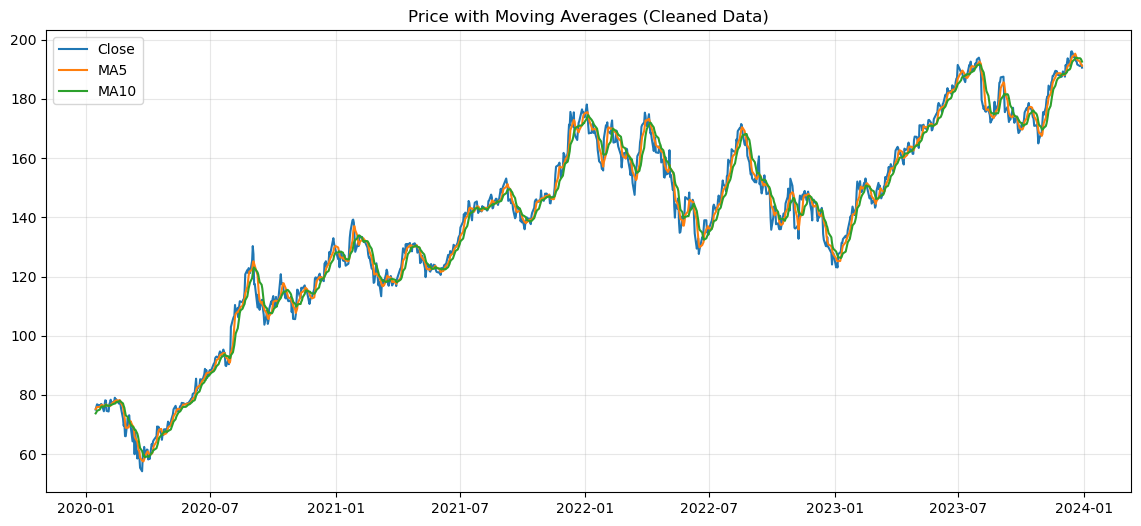

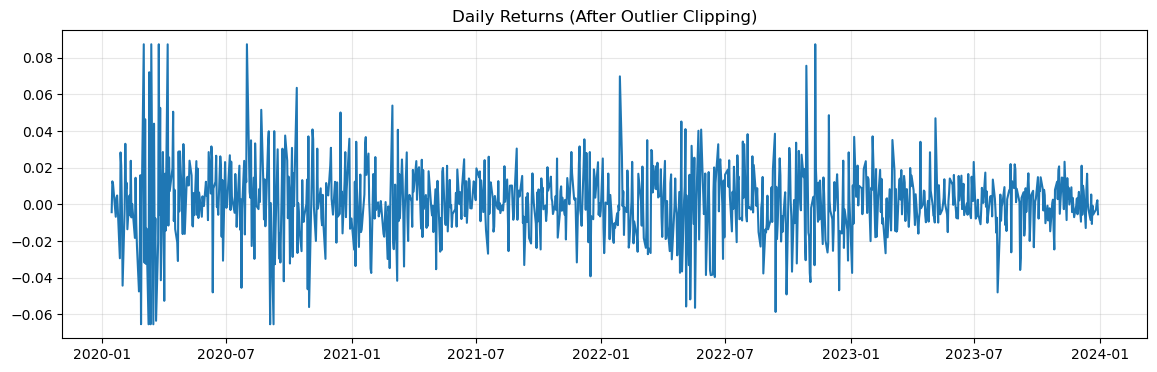

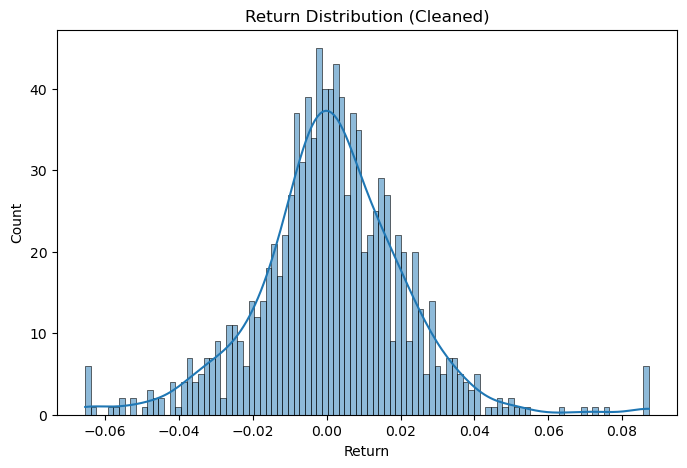

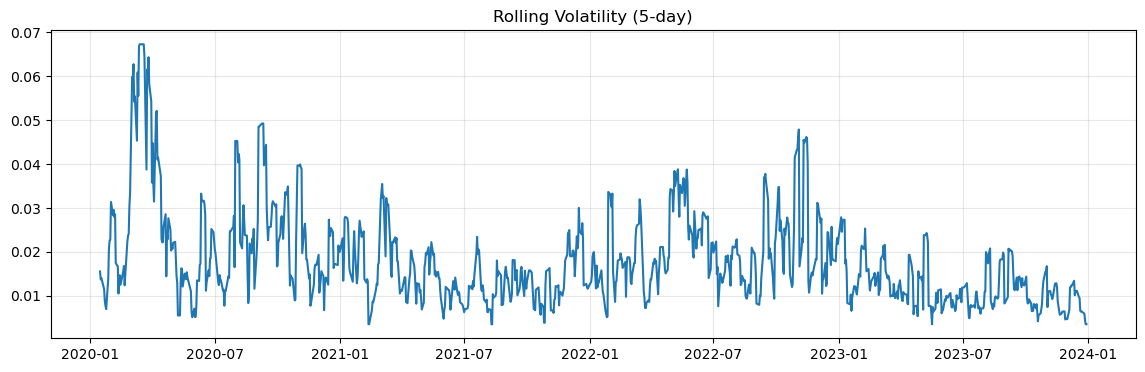

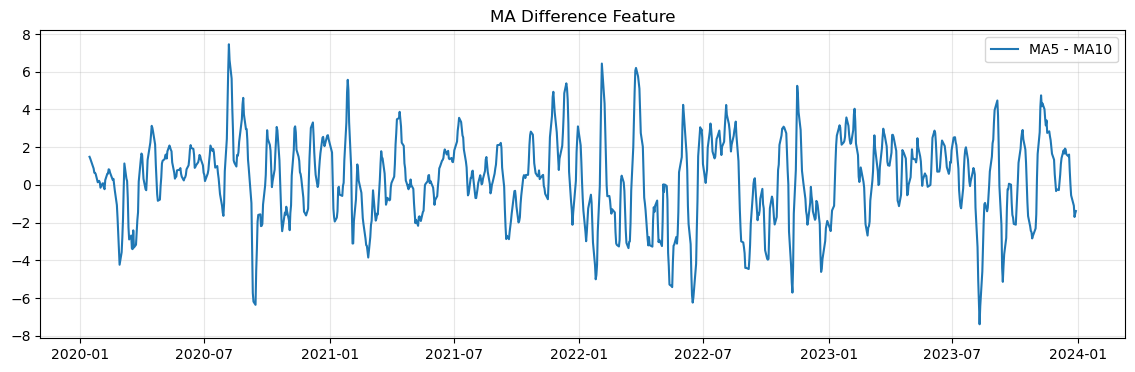

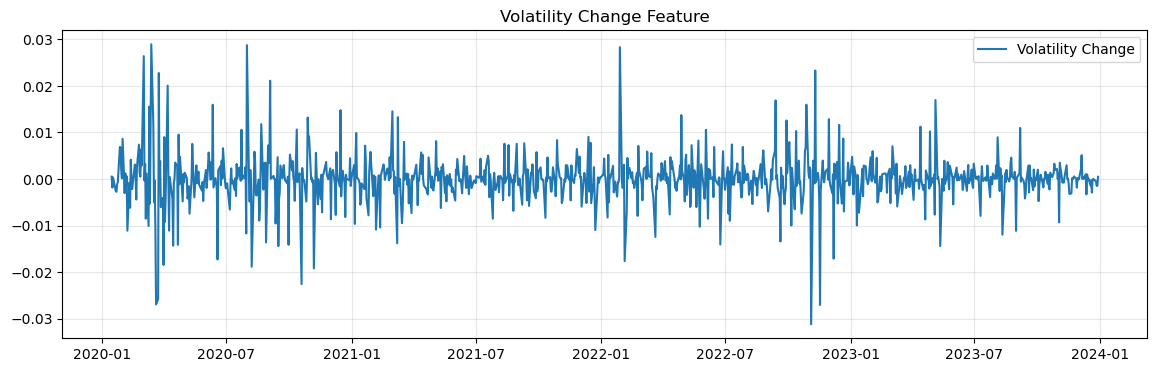

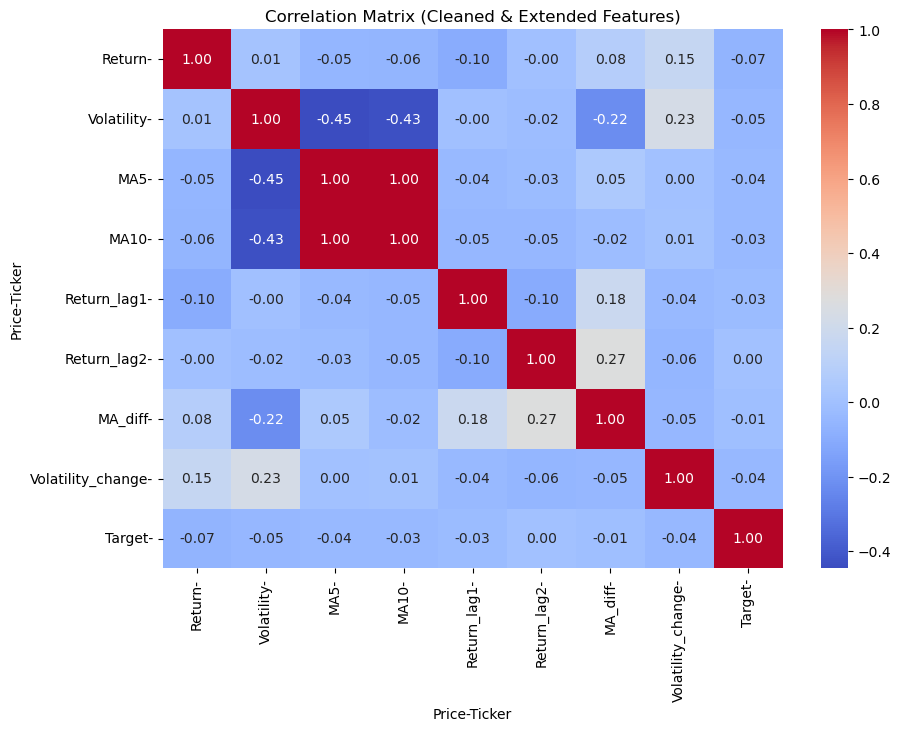

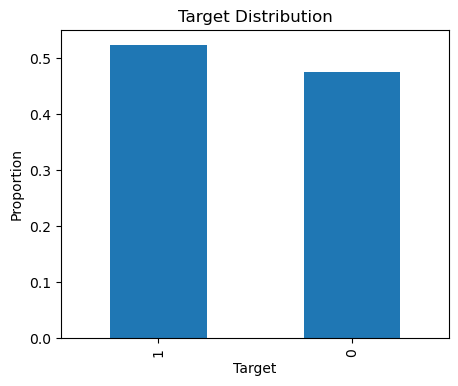

In [9]:
plt.figure(figsize=(14,6))
plt.plot(data.index, data["Close"], label="Close")
plt.plot(data.index, data["MA5"], label="MA5")
plt.plot(data.index, data["MA10"], label="MA10")
plt.title("Price with Moving Averages (Cleaned Data)")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

print()

plt.figure(figsize=(14,4))
plt.plot(data.index, data["Return"])
plt.title("Daily Returns (After Outlier Clipping)")
plt.grid(True, alpha=0.3)
plt.show()

print()

plt.figure(figsize=(8,5))
sns.histplot(data["Return"], bins=100, kde=True)
plt.title("Return Distribution (Cleaned)")
plt.show()

print()

plt.figure(figsize=(14,4))
plt.plot(data.index, data["Volatility"])
plt.title("Rolling Volatility (5-day)")
plt.grid(True, alpha=0.3)
plt.show()


print()

plt.figure(figsize=(14,4))
plt.plot(data.index, data["MA_diff"], label="MA5 - MA10")
plt.title("MA Difference Feature")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

print()

plt.figure(figsize=(14,4))
plt.plot(data.index, data["Volatility_change"], label="Volatility Change")
plt.title("Volatility Change Feature")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

print()

plt.figure(figsize=(10,7))
sns.heatmap(
    data[[
        "Return","Volatility","MA5","MA10",
        "Return_lag1","Return_lag2",
        "MA_diff","Volatility_change","Target"
    ]].corr(),
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)
plt.title("Correlation Matrix (Cleaned & Extended Features)")
plt.show()

print()

plt.figure(figsize=(5,4))
data["Target"].value_counts(normalize=True).plot(kind="bar")
plt.title("Target Distribution")
plt.ylabel("Proportion")
plt.show()

LogReg
Train: 0.5571
Test: 0.465
ROC: 0.5005

RandomForest
Train: 0.8243
Test: 0.51
ROC: 0.5318

XGBoost
Train: 1.0
Test: 0.5
ROC: 0.5326



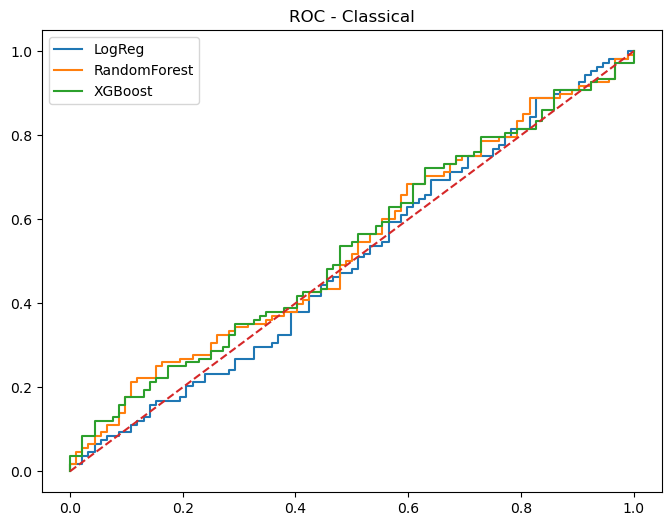

In [10]:
models = {
    "LogReg": LogisticRegression(max_iter=1000),
    "RandomForest": RandomForestClassifier(n_estimators=300, max_depth=6),
    "XGBoost": XGBClassifier()
}

results = []

plt.figure(figsize=(8,6))

for name, model in models.items():

    model.fit(X_train, y_train)

    train_acc = model.score(X_train, y_train)
    test_acc = model.score(X_test, y_test)

    probs = model.predict_proba(X_test)[:,1]
    roc = roc_auc_score(y_test, probs)

    results.append([name, train_acc, test_acc, roc, "Classical", "-"])

    print(name)
    print("Train:", round(train_acc,4))
    print("Test:", round(test_acc,4))
    print("ROC:", round(roc,4))
    print()

    fpr, tpr, _ = roc_curve(y_test, probs)
    plt.plot(fpr, tpr, label=name)

plt.plot([0,1],[0,1],'--')
plt.title("ROC - Classical")
plt.legend()
plt.show()

In [11]:
class CallbackOptimizer(COBYLA):
    def __init__(self, maxiter=100):
        super().__init__(maxiter=maxiter)
        self.history = []

    def minimize(self, fun, x0, jac=None, bounds=None):
        self.history = []

        def wrapped_fun(x):
            value = fun(x)
            self.history.append(value)
            print(f"Loss: {value:.4f}")
            return value

        result = super().minimize(wrapped_fun, x0, jac, bounds)
        result.history = self.history
        return result

def train_vqc(feature_map, ansatz, label, maxiter=100):

    optimizer = CallbackOptimizer(maxiter=maxiter)

    vqc = VQC(
        feature_map=feature_map,
        ansatz=ansatz,
        optimizer=optimizer
    )

    start = time.time()
    vqc.fit(X_train, y_train)
    train_time = time.time() - start

    train_acc = accuracy_score(y_train, vqc.predict(X_train))
    test_acc = accuracy_score(y_test, vqc.predict(X_test))
    probs = vqc.predict_proba(X_test)[:,1]
    roc = roc_auc_score(y_test, probs)

    print(f"{label} ROC: {roc:.4f} | Time: {train_time:.1f}s")

    return vqc, optimizer.history, train_acc, test_acc, roc, train_time

In [12]:
configs = {
    "ZZ_r1_RA_r2": (ZZFeatureMap(8, reps=1), RealAmplitudes(8, reps=2)),
    "ZZ_r2_RA_r2": (ZZFeatureMap(8, reps=2), RealAmplitudes(8, reps=2)),
    "ZZ_r2_RA_r3": (ZZFeatureMap(8, reps=2), RealAmplitudes(8, reps=3)),
    "Pauli_r1_RA_r2": (PauliFeatureMap(8, reps=1), RealAmplitudes(8, reps=2))
}

/tmp/ipykernel_1018549/3984748787.py:2: DeprecationWarning: The class ``qiskit.circuit.library.data_preparation._zz_feature_map.ZZFeatureMap`` is deprecated as of Qiskit 2.1. It will be removed in Qiskit 3.0. Use the zz_feature_map function as a replacement. Note that this will no longer return a BlueprintCircuit, but just a plain QuantumCircuit.
  "ZZ_r1_RA_r2": (ZZFeatureMap(8, reps=1), RealAmplitudes(8, reps=2)),
/tmp/ipykernel_1018549/3984748787.py:2: DeprecationWarning: The class ``qiskit.circuit.library.n_local.real_amplitudes.RealAmplitudes`` is deprecated as of Qiskit 2.1. It will be removed in Qiskit 3.0. Use the function qiskit.circuit.library.real_amplitudes instead.
  "ZZ_r1_RA_r2": (ZZFeatureMap(8, reps=1), RealAmplitudes(8, reps=2)),
/tmp/ipykernel_1018549/3984748787.py:3: DeprecationWarning: The class ``qiskit.circuit.library.data_preparation._zz_feature_map.ZZFeatureMap`` is deprecated as of Qiskit 2.1. It will be removed in Qiskit 3.0. Use the zz_feature_map function a

In [13]:
vqc_models = {}
loss_histories = {}
roc_scores = {}
train_times = {}

for name, (fmap, ansatz) in configs.items():

    print("\nTraining:", name)

    model, losses, train_acc, test_acc, roc, train_time = train_vqc(fmap, ansatz, name)

    vqc_models[name] = model
    loss_histories[name] = losses
    roc_scores[name] = roc
    train_times[name] = train_time

    results.append([name, train_acc, test_acc, roc, "Quantum", ansatz.num_parameters])

No gradient function provided, creating a gradient function. If your Sampler requires transpilation, please provide a pass manager.



Training: ZZ_r1_RA_r2
Loss: 1.0115
Loss: 1.0044
Loss: 1.0086
Loss: 1.0008
Loss: 1.0063
Loss: 1.0032
Loss: 0.9988
Loss: 1.0028
Loss: 0.9996
Loss: 0.9879
Loss: 0.9874
Loss: 0.9872
Loss: 0.9873
Loss: 0.9869
Loss: 0.9867
Loss: 0.9869
Loss: 0.9862
Loss: 0.9910
Loss: 0.9862
Loss: 0.9862
Loss: 0.9862
Loss: 0.9862
Loss: 0.9862
Loss: 0.9862
Loss: 0.9862
Loss: 0.9908
Loss: 0.9889
Loss: 0.9914
Loss: 0.9892
Loss: 0.9915
Loss: 0.9877
Loss: 0.9868
Loss: 0.9900
Loss: 0.9900
Loss: 0.9859
Loss: 0.9943
Loss: 0.9861
Loss: 0.9877
Loss: 0.9861
Loss: 0.9907
Loss: 0.9858
Loss: 0.9905
Loss: 0.9864
Loss: 0.9894
Loss: 0.9858
Loss: 0.9905
Loss: 0.9843
Loss: 0.9875
Loss: 0.9860
Loss: 0.9918
Loss: 0.9866
Loss: 0.9844
Loss: 0.9842
Loss: 0.9842
Loss: 0.9842
Loss: 0.9842
Loss: 0.9843
Loss: 0.9842
Loss: 0.9843
Loss: 0.9826
Loss: 0.9837
Loss: 0.9828
Loss: 0.9837
Loss: 0.9832
Loss: 0.9855
Loss: 0.9830
Loss: 0.9837
Loss: 0.9829
Loss: 0.9834
Loss: 0.9828
Loss: 0.9838
Loss: 0.9828
Loss: 0.9831
Loss: 0.9829
Loss: 0.9843
Lo

No gradient function provided, creating a gradient function. If your Sampler requires transpilation, please provide a pass manager.


ZZ_r1_RA_r2 ROC: 0.5037 | Time: 850.4s

Training: ZZ_r2_RA_r2
Loss: 0.9973
Loss: 0.9998
Loss: 0.9988
Loss: 0.9979
Loss: 0.9982
Loss: 0.9994
Loss: 0.9986
Loss: 0.9961
Loss: 0.9960
Loss: 0.9960
Loss: 0.9952
Loss: 0.9945
Loss: 0.9937
Loss: 0.9963
Loss: 0.9970
Loss: 0.9966
Loss: 0.9954
Loss: 1.0011
Loss: 0.9937
Loss: 0.9937
Loss: 0.9937
Loss: 0.9937
Loss: 0.9937
Loss: 0.9937
Loss: 0.9937
Loss: 0.9962
Loss: 0.9931
Loss: 0.9945
Loss: 0.9931
Loss: 0.9943
Loss: 0.9942
Loss: 0.9914
Loss: 0.9917
Loss: 0.9895
Loss: 0.9925
Loss: 0.9906
Loss: 0.9907
Loss: 0.9865
Loss: 0.9930
Loss: 0.9876
Loss: 0.9912
Loss: 0.9879
Loss: 0.9904
Loss: 0.9865
Loss: 0.9926
Loss: 0.9865
Loss: 0.9873
Loss: 0.9865
Loss: 0.9916
Loss: 0.9865
Loss: 0.9900
Loss: 0.9865
Loss: 0.9919
Loss: 0.9865
Loss: 0.9897
Loss: 0.9887
Loss: 0.9893
Loss: 0.9870
Loss: 0.9943
Loss: 0.9884
Loss: 0.9872
Loss: 0.9880
Loss: 0.9903
Loss: 0.9872
Loss: 0.9863
Loss: 0.9872
Loss: 0.9876
Loss: 0.9855
Loss: 0.9854
Loss: 0.9883
Loss: 0.9859
Loss: 0.9857
Lo

No gradient function provided, creating a gradient function. If your Sampler requires transpilation, please provide a pass manager.


ZZ_r2_RA_r2 ROC: 0.4478 | Time: 954.4s

Training: ZZ_r2_RA_r3
Loss: 0.9940
Loss: 1.0012
Loss: 0.9947
Loss: 0.9950
Loss: 0.9946
Loss: 0.9938
Loss: 0.9953
Loss: 0.9941
Loss: 0.9941
Loss: 0.9913
Loss: 0.9910
Loss: 0.9916
Loss: 0.9911
Loss: 0.9916
Loss: 0.9916
Loss: 0.9920
Loss: 0.9916
Loss: 0.9927
Loss: 0.9911
Loss: 0.9926
Loss: 0.9918
Loss: 0.9924
Loss: 0.9910
Loss: 0.9912
Loss: 0.9921
Loss: 0.9924
Loss: 0.9910
Loss: 0.9910
Loss: 0.9910
Loss: 0.9910
Loss: 0.9910
Loss: 0.9910
Loss: 0.9910
Loss: 0.9961
Loss: 0.9908
Loss: 0.9983
Loss: 0.9909
Loss: 0.9955
Loss: 0.9920
Loss: 0.9948
Loss: 0.9933
Loss: 0.9956
Loss: 0.9911
Loss: 0.9905
Loss: 0.9911
Loss: 0.9908
Loss: 0.9913
Loss: 0.9907
Loss: 0.9915
Loss: 0.9904
Loss: 0.9911
Loss: 0.9906
Loss: 0.9908
Loss: 0.9906
Loss: 0.9910
Loss: 0.9901
Loss: 0.9908
Loss: 0.9904
Loss: 0.9896
Loss: 0.9900
Loss: 0.9908
Loss: 0.9898
Loss: 0.9915
Loss: 0.9896
Loss: 0.9891
Loss: 0.9891
Loss: 0.9883
Loss: 0.9883
Loss: 0.9883
Loss: 0.9883
Loss: 0.9879
Loss: 0.9879
Lo

No gradient function provided, creating a gradient function. If your Sampler requires transpilation, please provide a pass manager.


ZZ_r2_RA_r3 ROC: 0.4923 | Time: 967.1s

Training: Pauli_r1_RA_r2
Loss: 1.0063
Loss: 1.0124
Loss: 1.0090
Loss: 1.0059
Loss: 1.0005
Loss: 1.0017
Loss: 1.0060
Loss: 1.0051
Loss: 1.0035
Loss: 0.9996
Loss: 0.9990
Loss: 0.9980
Loss: 0.9988
Loss: 0.9957
Loss: 0.9984
Loss: 0.9976
Loss: 0.9971
Loss: 0.9940
Loss: 0.9940
Loss: 0.9940
Loss: 0.9940
Loss: 0.9940
Loss: 0.9940
Loss: 0.9940
Loss: 0.9940
Loss: 0.9932
Loss: 0.9939
Loss: 0.9956
Loss: 0.9958
Loss: 0.9950
Loss: 0.9941
Loss: 0.9928
Loss: 0.9944
Loss: 0.9950
Loss: 0.9946
Loss: 0.9986
Loss: 0.9955
Loss: 0.9955
Loss: 0.9952
Loss: 0.9963
Loss: 0.9935
Loss: 0.9961
Loss: 0.9915
Loss: 0.9940
Loss: 0.9928
Loss: 0.9964
Loss: 0.9925
Loss: 0.9915
Loss: 0.9926
Loss: 0.9915
Loss: 0.9915
Loss: 0.9915
Loss: 0.9928
Loss: 0.9915
Loss: 0.9917
Loss: 0.9915
Loss: 0.9922
Loss: 0.9915
Loss: 0.9915
Loss: 0.9915
Loss: 0.9924
Loss: 0.9907
Loss: 0.9915
Loss: 0.9908
Loss: 0.9907
Loss: 0.9912
Loss: 0.9917
Loss: 0.9913
Loss: 0.9906
Loss: 0.9903
Loss: 0.9901
Loss: 0.9904

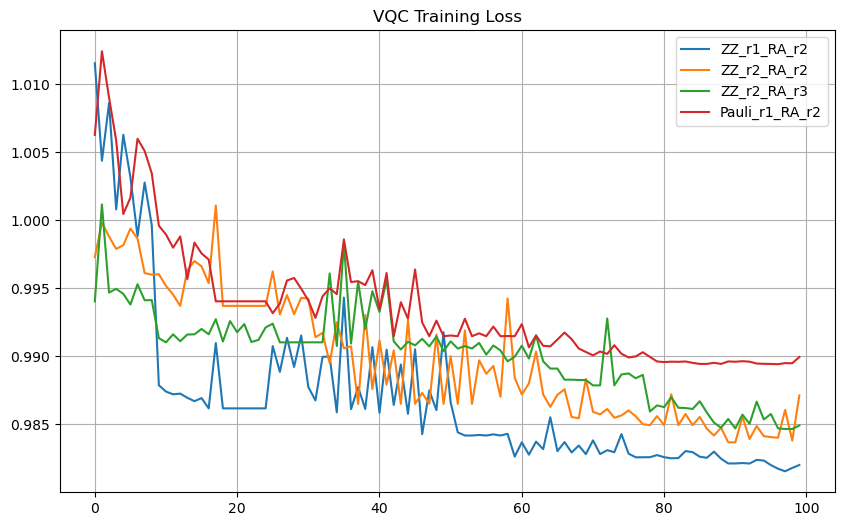

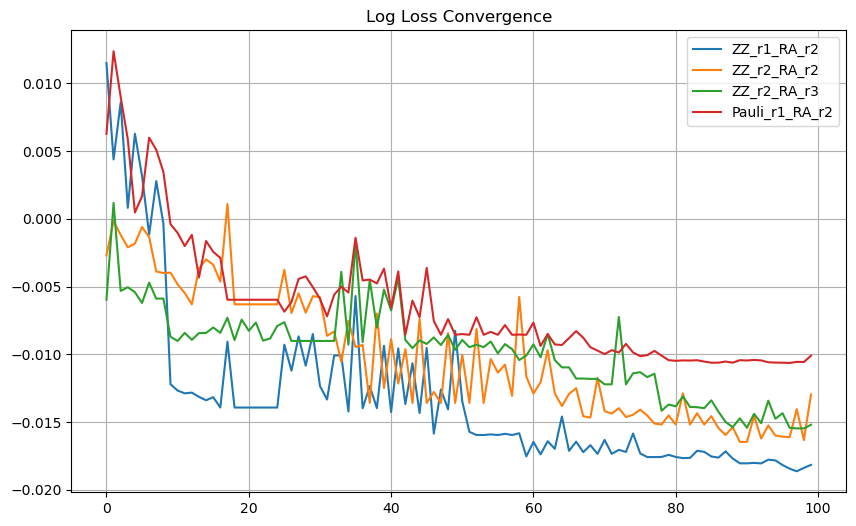

In [14]:
plt.figure(figsize=(10,6))
for name, losses in loss_histories.items():
    plt.plot(losses, label=name)
plt.title("VQC Training Loss")
plt.legend()
plt.grid(True)
plt.show()

plt.figure(figsize=(10,6))
for name, losses in loss_histories.items():
    plt.plot(np.log(losses), label=name)
plt.title("Log Loss Convergence")
plt.legend()
plt.grid(True)
plt.show()

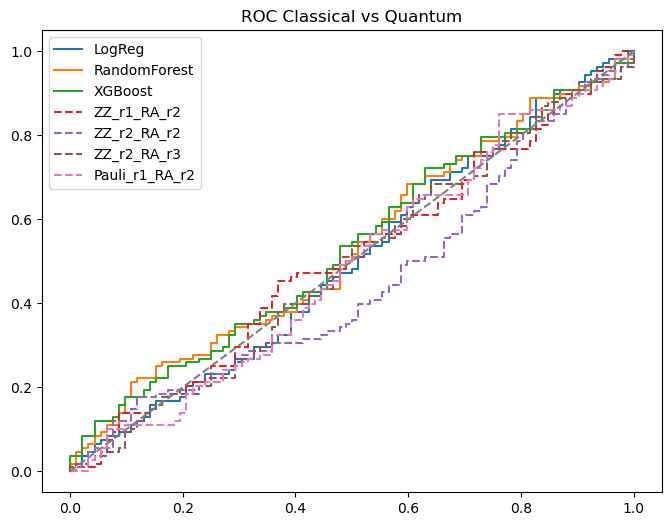

In [15]:
plt.figure(figsize=(8,6))

for name, model in models.items():
    probs = model.predict_proba(X_test)[:,1]
    fpr, tpr, _ = roc_curve(y_test, probs)
    plt.plot(fpr, tpr, label=name)

for name, model in vqc_models.items():
    probs = model.predict_proba(X_test)[:,1]
    fpr, tpr, _ = roc_curve(y_test, probs)
    plt.plot(fpr, tpr, linestyle="--", label=name)

plt.plot([0,1],[0,1],'--')
plt.legend()
plt.title("ROC Classical vs Quantum")
plt.show()

In [16]:
print("Stability check:\n")

for name, (fmap, ansatz) in configs.items():
    scores = []
    for seed in range(5):
        np.random.seed(seed)

        vqc_tmp = VQC(
            feature_map=fmap,
            ansatz=ansatz,
            optimizer=COBYLA(maxiter=50)
        )

        vqc_tmp.fit(X_train, y_train)

        probs = vqc_tmp.predict_proba(X_test)[:,1]
        scores.append(roc_auc_score(y_test, probs))

    print(name,
          "Mean:", round(np.mean(scores),4),
          "Std:", round(np.std(scores),4))

No gradient function provided, creating a gradient function. If your Sampler requires transpilation, please provide a pass manager.


Stability check:



No gradient function provided, creating a gradient function. If your Sampler requires transpilation, please provide a pass manager.
No gradient function provided, creating a gradient function. If your Sampler requires transpilation, please provide a pass manager.
No gradient function provided, creating a gradient function. If your Sampler requires transpilation, please provide a pass manager.
No gradient function provided, creating a gradient function. If your Sampler requires transpilation, please provide a pass manager.
No gradient function provided, creating a gradient function. If your Sampler requires transpilation, please provide a pass manager.


ZZ_r1_RA_r2 Mean: 0.4761 Std: 0.019


No gradient function provided, creating a gradient function. If your Sampler requires transpilation, please provide a pass manager.
No gradient function provided, creating a gradient function. If your Sampler requires transpilation, please provide a pass manager.
No gradient function provided, creating a gradient function. If your Sampler requires transpilation, please provide a pass manager.
No gradient function provided, creating a gradient function. If your Sampler requires transpilation, please provide a pass manager.
No gradient function provided, creating a gradient function. If your Sampler requires transpilation, please provide a pass manager.


ZZ_r2_RA_r2 Mean: 0.501 Std: 0.0224


No gradient function provided, creating a gradient function. If your Sampler requires transpilation, please provide a pass manager.
No gradient function provided, creating a gradient function. If your Sampler requires transpilation, please provide a pass manager.
No gradient function provided, creating a gradient function. If your Sampler requires transpilation, please provide a pass manager.
No gradient function provided, creating a gradient function. If your Sampler requires transpilation, please provide a pass manager.
No gradient function provided, creating a gradient function. If your Sampler requires transpilation, please provide a pass manager.


ZZ_r2_RA_r3 Mean: 0.4954 Std: 0.0296


No gradient function provided, creating a gradient function. If your Sampler requires transpilation, please provide a pass manager.
No gradient function provided, creating a gradient function. If your Sampler requires transpilation, please provide a pass manager.
No gradient function provided, creating a gradient function. If your Sampler requires transpilation, please provide a pass manager.
No gradient function provided, creating a gradient function. If your Sampler requires transpilation, please provide a pass manager.


Pauli_r1_RA_r2 Mean: 0.5198 Std: 0.0162


In [37]:
def run_stacking(base_model, base_name):
    meta_X_train = np.column_stack([
        base_model.predict_proba(X_train)[:, 1],
        vqc_models["ZZ_r1_RA_r2"].predict_proba(X_train)[:, 1]
    ])

    meta_X_test = np.column_stack([
        base_model.predict_proba(X_test)[:, 1],
        vqc_models["ZZ_r1_RA_r2"].predict_proba(X_test)[:, 1]
    ])

    meta_model = LogisticRegression()
    meta_model.fit(meta_X_train, y_train)

    meta_train_probs = meta_model.predict_proba(meta_X_train)[:, 1]
    meta_train_preds = (meta_train_probs > 0.5).astype(int)
    meta_train_acc = accuracy_score(y_train, meta_train_preds)

    meta_test_probs = meta_model.predict_proba(meta_X_test)[:, 1]
    meta_test_preds = (meta_test_probs > 0.5).astype(int)

    meta_test_roc = roc_auc_score(y_test, meta_test_probs)
    meta_test_acc = accuracy_score(y_test, meta_test_preds)

    print(f"Stacking {base_name} + VQC:")
    print("Train Accuracy:", round(meta_train_acc, 4))
    print("Test Accuracy:", round(meta_test_acc, 4))
    print("ROC-AUC:", round(meta_test_roc, 4))
    print()

    return (
        meta_train_acc,
        meta_test_acc,
        meta_test_roc,
        meta_test_preds,
        meta_model,        
        meta_X_test        
    )

In [38]:
train_acc_rf, test_acc_rf, roc_rf, preds_rf, meta_model_rf, meta_X_test_rf = run_stacking(models["RandomForest"], "RF")

train_acc_xgb, test_acc_xgb, roc_xgb, preds_xgb, meta_model_xgb, meta_X_test_xgb = run_stacking(models["XGBoost"], "XGB")

Stacking RF + VQC:
Train Accuracy: 0.8657
Test Accuracy: 0.49
ROC-AUC: 0.5308

Stacking XGB + VQC:
Train Accuracy: 1.0
Test Accuracy: 0.5
ROC-AUC: 0.5322



In [39]:
results.append(["Stacking_RF_VQC", train_acc_rf, test_acc_rf, roc_rf, "Hybrid", 2])
results.append(["Stacking_XGB_VQC", train_acc_xgb, test_acc_xgb, roc_xgb, "Hybrid", 2])

results_df = pd.DataFrame(results,
    columns=["Model","Train Acc","Test Acc","ROC-AUC","Type","Parameters"])

results_df = results_df.drop_duplicates(subset='Model', keep='first')

print("Final Results:\n")
print(results_df)

Final Results:

              Model  Train Acc  Test Acc   ROC-AUC       Type Parameters
0            LogReg   0.557089     0.465  0.500503  Classical          -
1      RandomForest   0.824341     0.510  0.531804  Classical          -
2           XGBoost   1.000000     0.500  0.532609  Classical          -
3       ZZ_r1_RA_r2   0.597240     0.505  0.503724    Quantum         24
4       ZZ_r2_RA_r2   0.584693     0.450  0.447766    Quantum         24
5       ZZ_r2_RA_r3   0.558344     0.515  0.492250    Quantum         32
6    Pauli_r1_RA_r2   0.552070     0.510  0.488627    Quantum         24
7   Stacking_RF_VQC   0.865747     0.490  0.530797     Hybrid          2
8  Stacking_XGB_VQC   1.000000     0.500  0.532206     Hybrid          2


In [40]:
f1_scores = []

for name, model in models.items():
    preds = model.predict(X_test)
    f1_scores.append(f1_score(y_test, preds))

for name, model in vqc_models.items():
    preds = model.predict(X_test)
    f1_scores.append(f1_score(y_test, preds))

f1_scores.append(f1_score(y_test, preds_rf))
f1_scores.append(f1_score(y_test, preds_xgb))

results_df["F1 Score"] = f1_scores

print("Final Results with F1:\n")
print(results_df)

Final Results with F1:

              Model  Train Acc  Test Acc   ROC-AUC       Type Parameters  \
0            LogReg   0.557089     0.465  0.500503  Classical          -   
1      RandomForest   0.824341     0.510  0.531804  Classical          -   
2           XGBoost   1.000000     0.500  0.532609  Classical          -   
3       ZZ_r1_RA_r2   0.597240     0.505  0.503724    Quantum         24   
4       ZZ_r2_RA_r2   0.584693     0.450  0.447766    Quantum         24   
5       ZZ_r2_RA_r3   0.558344     0.515  0.492250    Quantum         32   
6    Pauli_r1_RA_r2   0.552070     0.510  0.488627    Quantum         24   
7   Stacking_RF_VQC   0.865747     0.490  0.530797     Hybrid          2   
8  Stacking_XGB_VQC   1.000000     0.500  0.532206     Hybrid          2   

   F1 Score  
0  0.343558  
1  0.289855  
2  0.444444  
3  0.526316  
4  0.490741  
5  0.544601  
6  0.558559  
7  0.190476  
8  0.444444  


<Figure size 640x480 with 0 Axes>

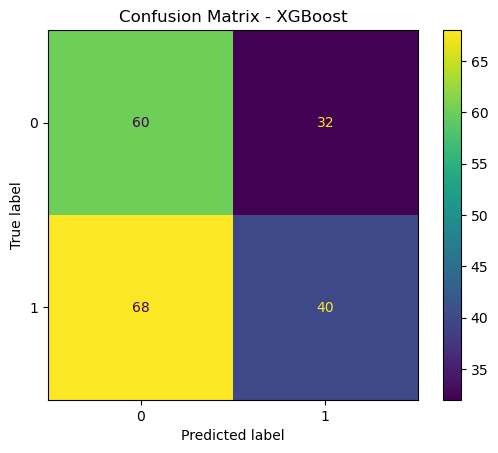

<Figure size 640x480 with 0 Axes>

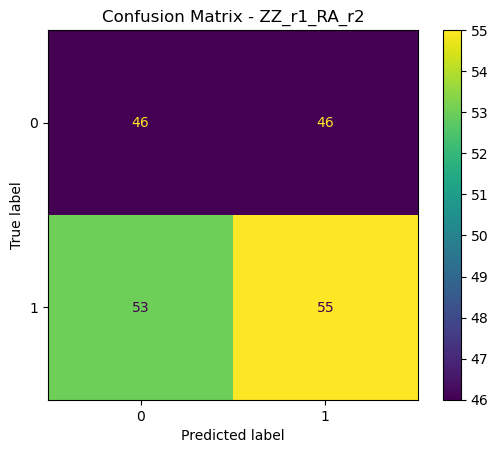

In [41]:
best_classical = max(models.items(),
                     key=lambda x: roc_auc_score(y_test, x[1].predict_proba(X_test)[:,1]))

best_quantum = max(vqc_models.items(),
                   key=lambda x: roc_auc_score(y_test, x[1].predict_proba(X_test)[:,1]))

plt.figure()
ConfusionMatrixDisplay.from_predictions(
    y_test,
    best_classical[1].predict(X_test)
)
plt.title(f"Confusion Matrix - {best_classical[0]}")
plt.show()

plt.figure()
ConfusionMatrixDisplay.from_predictions(
    y_test,
    best_quantum[1].predict(X_test)
)
plt.title(f"Confusion Matrix - {best_quantum[0]}")
plt.show()

Stacking model coefficients:
  RandomForestфс weight: 11.023
  VQC weight: 1.465
  Intercept: -6.460


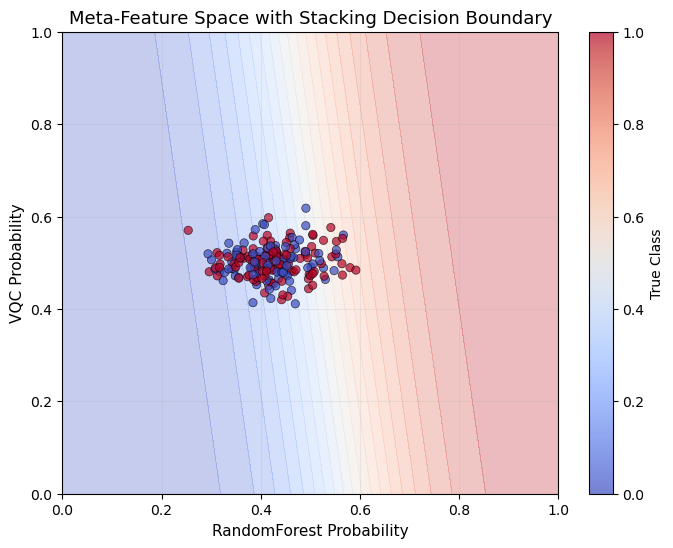

In [42]:
meta_model = meta_model_rf
meta_X_test = meta_X_test_rf

plt.figure(figsize=(8,6))

xx, yy = np.meshgrid(np.linspace(0, 1, 100), np.linspace(0, 1, 100))
grid = np.c_[xx.ravel(), yy.ravel()]
Z = meta_model.predict_proba(grid)[:, 1].reshape(xx.shape)

plt.contourf(xx, yy, Z, levels=20, cmap="coolwarm", alpha=0.3)

scatter = plt.scatter(meta_X_test[:,0], meta_X_test[:,1],
                      c=y_test, cmap="coolwarm",
                      edgecolors='black', linewidth=0.5, alpha=0.7)

plt.colorbar(scatter, label="True Class")
plt.xlabel("RandomForest Probability", fontsize=11)
plt.ylabel("VQC Probability", fontsize=11)
plt.title("RandomForest + VQC Stacking", fontsize=13)
plt.xlim(0, 1)
plt.ylim(0, 1)
plt.grid(True, alpha=0.2)

print("Stacking model coefficients:")
print(f"RandomForestфс weight: {meta_model.coef_[0][0]:.3f}")
print(f"VQC weight: {meta_model.coef_[0][1]:.3f}")
print(f"Intercept: {meta_model.intercept_[0]:.3f}")
plt.show()

Stacking model coefficients:
  XGB weight: 8.603
  VQC weight: 0.136
  Intercept: -4.364


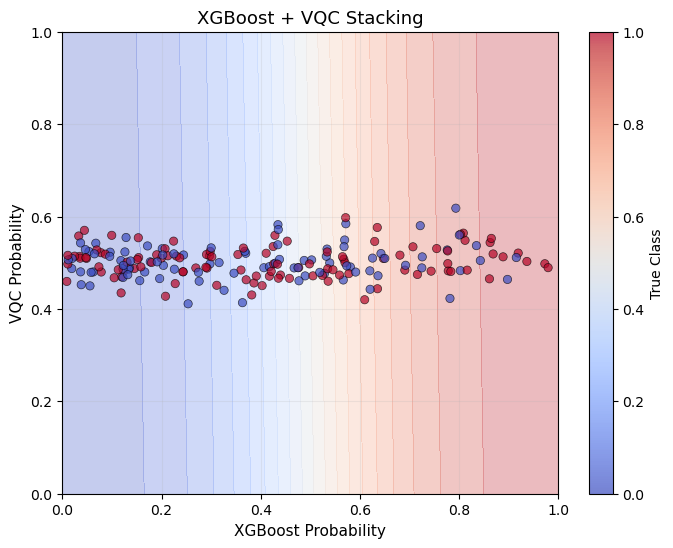

In [43]:
xx, yy = np.meshgrid(np.linspace(0, 1, 100),
                     np.linspace(0, 1, 100))
grid = np.c_[xx.ravel(), yy.ravel()]

Z = meta_model_xgb.predict_proba(grid)[:, 1].reshape(xx.shape)

plt.figure(figsize=(8,6))

plt.contourf(xx, yy, Z, levels=20, cmap="coolwarm", alpha=0.3)

scatter = plt.scatter(
    meta_X_test_xgb[:,0],
    meta_X_test_xgb[:,1],
    c=y_test,
    cmap="coolwarm",
    edgecolors='black',
    linewidth=0.5,
    alpha=0.7
)

plt.colorbar(scatter, label="True Class")

plt.xlabel("XGBoost Probability", fontsize=11)
plt.ylabel("VQC Probability", fontsize=11)
plt.title("XGBoost + VQC Stacking", fontsize=13)

plt.xlim(0, 1)
plt.ylim(0, 1)
plt.grid(True, alpha=0.2)

print("Stacking model coefficients:")
print(f"XGB weight: {meta_model_xgb.coef_[0][0]:.3f}")
print(f"VQC weight: {meta_model_xgb.coef_[0][1]:.3f}")
print(f"Intercept: {meta_model_xgb.intercept_[0]:.3f}")

plt.show()

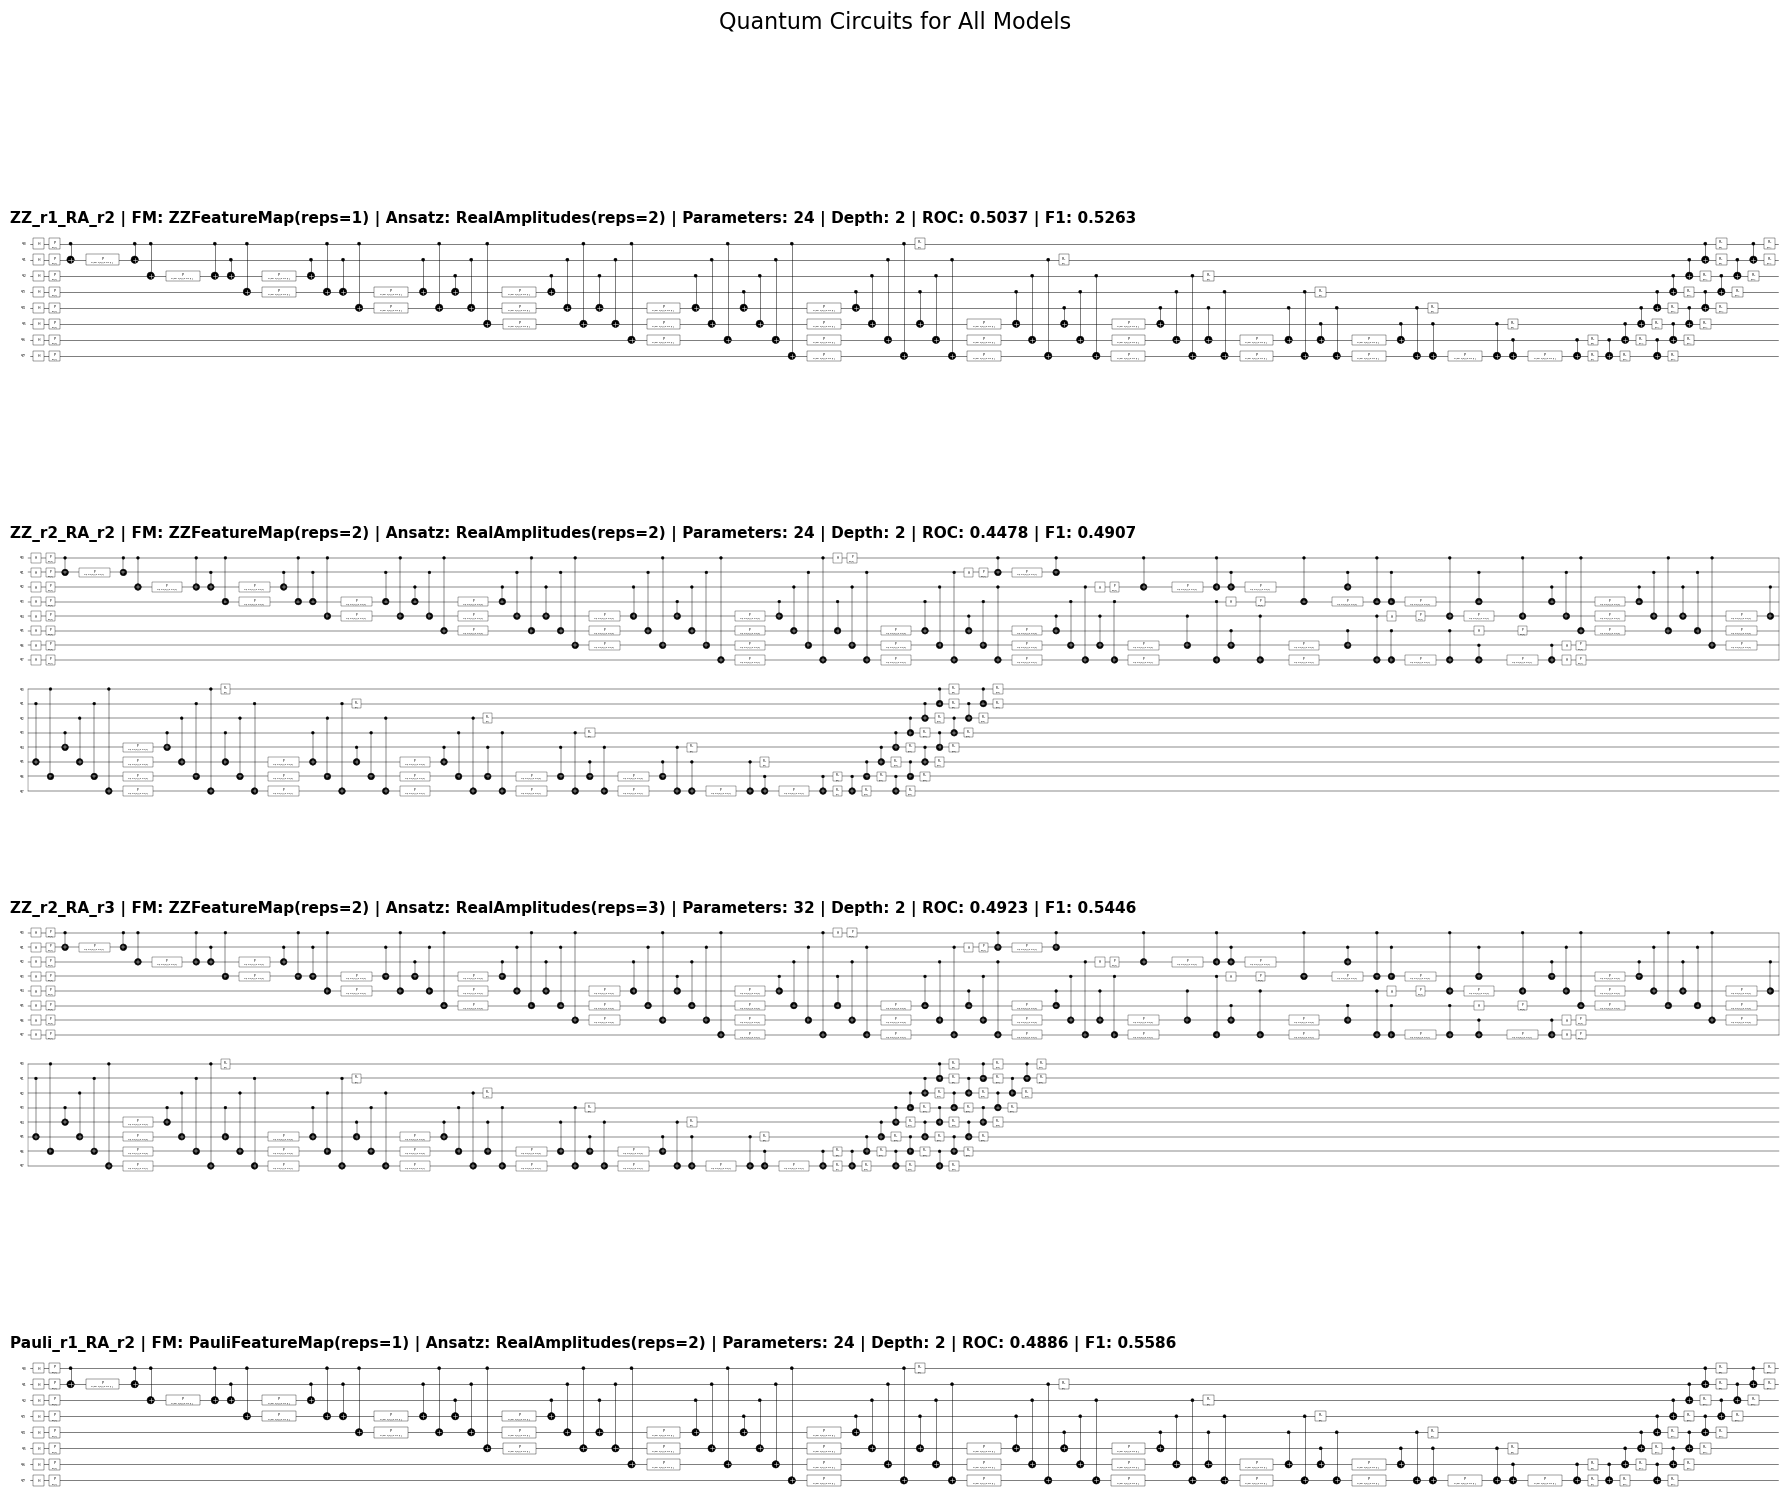

In [45]:
quantum_models = list(configs.items())

fig, axes = plt.subplots(len(quantum_models), 1, figsize=(18, 4*len(quantum_models)))

if len(quantum_models) == 1:
    axes = [axes]

for idx, (name, (fmap, ansatz)) in enumerate(quantum_models):
    full_circuit = fmap.compose(ansatz)

    ax = axes[idx]
    circuit_drawer(full_circuit.decompose(), output='mpl', style={'name': 'bw'},
                   scale=0.6, ax=ax, plot_barriers=False, fold=120)

    roc_val = roc_scores.get(name, 0)
    f1_val = results_df[results_df["Model"] == name]["F1 Score"].values[0]

    ax.set_title(f"{name} | FM: {type(fmap).__name__}(reps={fmap.reps}) | "
                 f"Ansatz: {type(ansatz).__name__}(reps={ansatz.reps}) | "
                 f"Parameters: {ansatz.num_parameters} | Depth: {full_circuit.depth()} | "
                 f"ROC: {roc_val:.4f} | F1: {f1_val:.4f}",
                 fontsize=11, fontweight='bold', loc='left')

plt.suptitle("Quantum Circuits for All Models", fontsize=16, y=1.02)
plt.tight_layout()
plt.show()

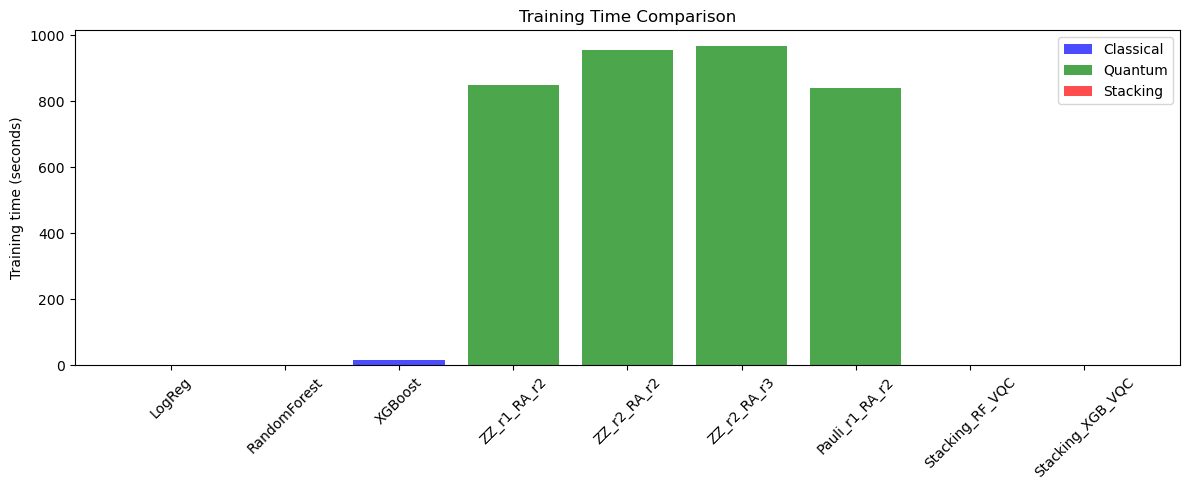

Classical times: [0.001, 0.265, 15.205]
Quantum times: [850.438, 954.425, 967.076, 841.566]
Stacking times: [0.1, 0.1]


In [46]:
classical_times = []
quantum_times = []
stacking_times = [0.1, 0.1]  

for name, model in models.items():
    if hasattr(model, 'fit_time'):
        classical_times.append(model.fit_time)
    else:
        start = time.time()
        model.fit(X_train, y_train)
        classical_times.append(time.time() - start)

for name in vqc_models.keys():
    quantum_times.append(train_times[name])

stacking_models = {
    "Stacking_RF_VQC": meta_model_rf,
    "Stacking_XGB_VQC": meta_model_xgb
}

labels_classical = list(models.keys())
labels_quantum = list(vqc_models.keys())
labels_stacking = list(stacking_models.keys())

plt.figure(figsize=(12,5))

plt.bar(labels_classical, classical_times, label="Classical", color='blue', alpha=0.7)
plt.bar(labels_quantum, quantum_times, label="Quantum", color='green', alpha=0.7)
plt.bar(labels_stacking, stacking_times, label="Stacking", color='red', alpha=0.7)

plt.ylabel("Training time (seconds)")
plt.title("Training Time Comparison")
plt.legend()
plt.xticks(rotation=45) 
plt.tight_layout()
plt.show()

print("Classical times:", [round(t, 3) for t in classical_times])
print("Quantum times:", [round(t, 3) for t in quantum_times])
print("Stacking times:", stacking_times)

In [47]:
def measure_inference(model, X, n_runs=100):
    start = time.time()
    for _ in range(n_runs):
        model.predict(X)
    return (time.time() - start) / n_runs

print("Inference Time (seconds per prediction batch):\n")

for name, model in models.items():
    t = measure_inference(model, X_test)
    print(f"{name}: {t:.6f}")

for name, model in vqc_models.items():
    t = measure_inference(model, X_test)
    print(f"{name}: {t:.6f}")

for name, model in stacking_models.items():
    X = meta_X_test_rf if 'RF' in name else meta_X_test_xgb
    t = measure_inference(model, X)
    print(f"{name}: {t:.6f}")

Inference Time (seconds per prediction batch):

LogReg: 0.000031
RandomForest: 0.009065
XGBoost: 0.017619
ZZ_r1_RA_r2: 2.145430
ZZ_r2_RA_r2: 2.419072
ZZ_r2_RA_r3: 2.464317
Pauli_r1_RA_r2: 2.112150
Stacking_RF_VQC: 0.000026
Stacking_XGB_VQC: 0.000024


In [48]:
print("Model complexity:\n")

for name, model in models.items():
    if hasattr(model, "coef_"):
        params = model.coef_.size
    elif hasattr(model, "feature_importances_"):
        params = len(model.feature_importances_)
    else:
        params = "unknown"
    print(f"{name} parameters: {params}")

for name, (fmap, ansatz) in configs.items():
    print(f"{name} quantum parameters: {ansatz.num_parameters}")

for name, model in stacking_models.items():
    print(f"{name} parameters: {model.coef_.size + len(model.intercept_)}")

Model complexity:

LogReg parameters: 8
RandomForest parameters: 8
XGBoost parameters: 8
ZZ_r1_RA_r2 quantum parameters: 24
ZZ_r2_RA_r2 quantum parameters: 24
ZZ_r2_RA_r3 quantum parameters: 32
Pauli_r1_RA_r2 quantum parameters: 24
Stacking_RF_VQC parameters: 3
Stacking_XGB_VQC parameters: 3


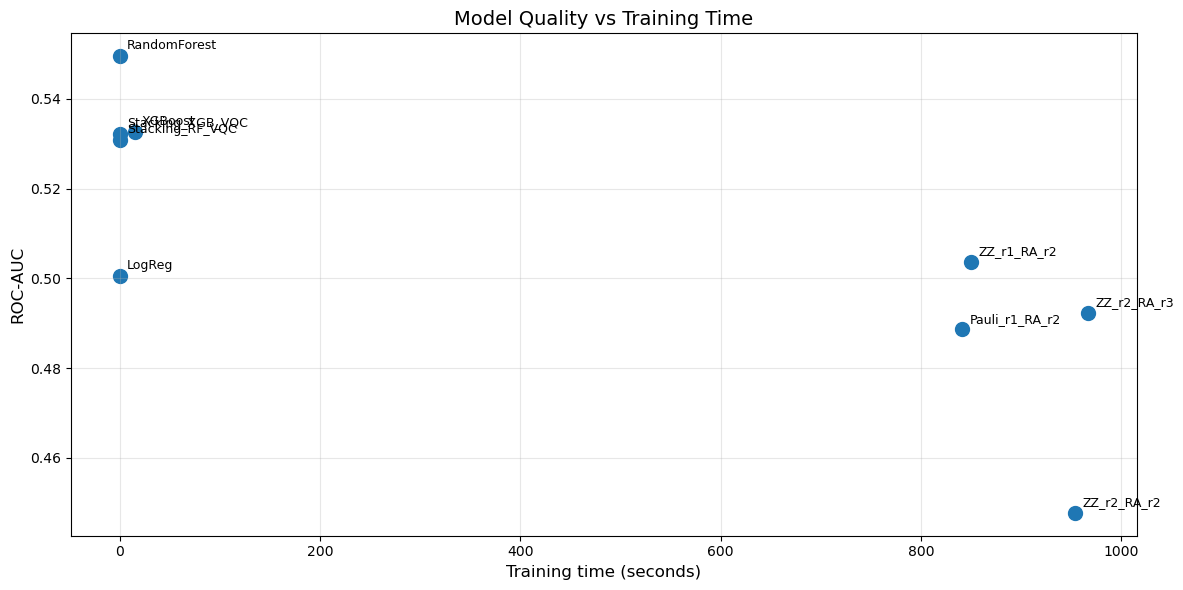


Summary:
LogReg: ROC=0.5005, Time=0.00s
RandomForest: ROC=0.5495, Time=0.26s
XGBoost: ROC=0.5326, Time=15.20s
ZZ_r1_RA_r2: ROC=0.5037, Time=850.44s
ZZ_r2_RA_r2: ROC=0.4478, Time=954.43s
ZZ_r2_RA_r3: ROC=0.4923, Time=967.08s
Pauli_r1_RA_r2: ROC=0.4886, Time=841.57s
Stacking_RF_VQC: ROC=0.5308, Time=0.10s
Stacking_XGB_VQC: ROC=0.5322, Time=0.10s


In [49]:
roc_vals = []
time_vals = []
labels = []

for name, model in models.items():
    probs = model.predict_proba(X_test)[:,1]
    roc = roc_auc_score(y_test, probs)
    roc_vals.append(roc)
    time_vals.append(classical_times[list(models.keys()).index(name)])
    labels.append(name)

for name in vqc_models.keys():
    roc_vals.append(roc_scores[name])
    time_vals.append(train_times[name])
    labels.append(name)

for name, model in stacking_models.items():
    X = meta_X_test_rf if 'RF' in name else meta_X_test_xgb
    probs = model.predict_proba(X)[:,1]
    roc = roc_auc_score(y_test, probs)
    roc_vals.append(roc)
    time_vals.append(0.1) 
    labels.append(name)

plt.figure(figsize=(12,6))
plt.scatter(time_vals, roc_vals, s=100)a

for i, label in enumerate(labels):
    plt.annotate(label, (time_vals[i], roc_vals[i]), 
                xytext=(5, 5), textcoords='offset points', fontsize=9)

plt.xlabel("Training time (seconds)", fontsize=12)
plt.ylabel("ROC-AUC", fontsize=12)
plt.title("Model Quality vs Training Time", fontsize=14)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print("\nSummary:")
for i, label in enumerate(labels):
    print(f"{label}: ROC={roc_vals[i]:.4f}, Time={time_vals[i]:.2f}s")

In [56]:
import joblib
import os
import tempfile
import numpy as np

def get_model_size(model):
    try:
        with tempfile.NamedTemporaryFile(suffix=".pkl", delete=False) as f:
            joblib.dump(model, f.name)
            size = os.path.getsize(f.name) / (1024 * 1024)  
        os.unlink(f.name)
        return size, None 

    except Exception:
        if hasattr(model, "weights"):
            weights = model.weights
            size = weights.nbytes / (1024 * 1024)
            return size, len(weights) 
        
        return None, None


all_models = {**models, **vqc_models, **stacking_models}

print("Model memory usage:\n")

size_dict = {}

for name, model in all_models.items():
    size, n_params = get_model_size(model)
    size_dict[name] = size

    if size is not None:
        if n_params is not None:
            print(f"{name}: {size:.6f} MB ({n_params} params)")
        else:
            print(f"{name}: {size:.6f} MB")
    else:
        print(f"{name}: cannot be measured")

def avg_size(model_dict):
    sizes = [
        size_dict[name]
        for name in model_dict
        if name in size_dict and size_dict[name] is not None
    ]
    return sum(sizes) / len(sizes) if sizes else 0


print("\nAverage memory usage:")
print(f"Classical: {avg_size(models):.6f} MB")
print(f"Quantum: {avg_size(vqc_models):.6f} MB")
print(f"Stacking: {avg_size(stacking_models):.6f} MB")


print("\nNote:")
print("Quantum model size is estimated using only trainable weights (not full object),")
print("because Qiskit VQC models cannot be reliably serialized.")

Model memory usage:

LogReg: 0.000884 MB
RandomForest: 1.477212 MB
XGBoost: 0.195177 MB
ZZ_r1_RA_r2: 0.000183 MB (24 params)
ZZ_r2_RA_r2: 0.000183 MB (24 params)
ZZ_r2_RA_r3: 0.000244 MB (32 params)
Pauli_r1_RA_r2: 0.000183 MB (24 params)
Stacking_RF_VQC: 0.000823 MB
Stacking_XGB_VQC: 0.000823 MB

Average memory usage:
Classical: 0.557758 MB
Quantum: 0.000198 MB
Stacking: 0.000823 MB

Note:
Quantum model size is estimated using only trainable weights (not full object),
because Qiskit VQC models cannot be reliably serialized.
